In [2]:
import torch
import ray
import sys, os
from typing import Optional, Union, List
import multiprocessing
import numpy as np
#import faiss
import mdtraj as md
import matplotlib.pyplot as plt
from seaborn import kdeplot

from writhe_tools.md_tools import (traj_slice, Rg, ResidueDistances,
                                   calc_sa, tangent_corr, bending_energy,
                                   get_residues, to_distance_matrix, to_contacts)

from writhe_tools.md_tools import curvature_menger as curvature
from writhe_tools.utils import lsdir, load_dict, combinations, save_dict, load_dict, group_by, reindex_list, Timer
from writhe_tools.writhe import Writhe, window_average, to_laplacian
from writhe_tools.plots import (subplots_proj2d, subplots_fes2d, lineplot1D,
                                box_plot, plot_distance_matrix, build_matrix_boxplot_grid,
                                build_grid_plot, annotated_matrix_plot, fes2d, proj2d)
from writhe_tools.tcca import tCCA
from writhe_tools.stats import pca, standardize, get_extrema, MaxEntropyReweight, std, mean, rmse, cov

from tools import block_error, ci_filter







helix_pdb = '/data/writhe/actr/actr.helix.pdb'
obs_path = '/data/top_complexity/observables/actr'
exp_cs_file = '/data/top_complexity/observables/actr/exp_cs.dat'

names = ['a99', 'CALVADOS', 'bAIes', 'BioEMU', 'STARLING', 'Coil']
labels = ['a99SB-disp', 'CALVADOS', 'bAIes', 'bioemu', 'STARLING', 'coil']
need_slice = [True, False, True, True, True, True]
colors = ['steelblue', 'orange','olivedrab', 'indianred', 'gray', 'purple']

protein_names = [ r'A$\beta$40', 'ACTR', r'$\alpha$Synuclein']

weights_files = [f'{obs_path}/{i}' for i in ['weights_cs', 'weights_pre', 'weights_all']]



from writhe_tools.plots import fes2d, proj2d


n_classes = len(colors)
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(colors)
bounds = np.arange(0, n_classes , 1)          # [-0.5, 0.5, 1.5, ...]
norm = BoundaryNorm(bounds, cmap.N)

[writhe_tools] ⏭️ Skipping 'graph_utils' (missing: torch_geometric)
[writhe_tools] 👉 To enable this module, install: pip install writhe-tools[graph]


In [3]:
files = { 'ab40' : {'pdb' : ["/data/r1r2/kaush/ab40/Ab40.pdb",
                    "/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.pdb",
                    "/data/top_complexity/bAIes/Ab40.pdb",
                    "/data/top_complexity/bioemu_ensembles/Ab40/topology_ready.pdb",
                    "/data/top_complexity/starling/ab40/ab40_starling_all.pdb",
                    "/data/top_complexity/bAIes/Ab40.pdb"
                    
                    
                   ],
           'dcd' : ["/data/r1r2/kaush/ab40/Ab40-a99SBdisp-Traj.dcd",
                     "/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.xtc",
                     "/data/top_complexity/bAIes/traj_Ab40_bAIes.xtc",
                     "/data/top_complexity/bioemu_ensembles/Ab40/samples_ready.xtc",
                     "/data/top_complexity/starling/ab40/ab40_starling_all.xtc",
                     "/data/top_complexity/bAIes/traj_Ab40_coil.xtc",
                   ]  
           
          },
    
    
    
    
    'actr' : {'pdb' : ["/data/writhe/actr/actr.pdb",
                    "/data/top_complexity/calvados2_ensembles/ACTR/ACTR_converted.pdb",
                    "/data/top_complexity/bAIes/ACTR.pdb",
                    "/data/top_complexity/bioemu_ensembles/ACTR/topology_ready.pdb",
                    "/data/top_complexity/starling/actr/actr_starling_all.pdb",
                    "/data/top_complexity/bAIes/ACTR.pdb"],
           'dcd' : [
                   "/data/writhe/actr/ACTR-a99SBdisp-Traj.dcd",
                   "/data/top_complexity/calvados2_ensembles/ACTR/ACTR_converted.xtc",
                   "/data/top_complexity/bAIes/traj_ACTR_bAIes.xtc",
                   "/data/top_complexity/bioemu_ensembles/ACTR/samples_ready.xtc",
                   "/data/top_complexity/starling/actr/actr_starling_all.xtc",
                   "/data/top_complexity/bAIes/traj_ACTR_coil.xtc"]
          },
 

 'asyn' : {'pdb' : ["/data/writhe/asyn/full/apo/asyn_full_lig47_trunc.protein.pdb",  
                    "/data/top_complexity/calvados2_ensembles/asyn/asyn_converted.pdb",
                    "/data/top_complexity/bAIes/asyn.pdb",
                    "/data/top_complexity/bioemu_ensembles/asyn/topology_ready.pdb",
                    "/data/top_complexity/starling/asyn/asyn_starling.pdb",
                    "/data/top_complexity/bAIes/asyn.pdb",
                   ],
           'dcd' : ["/data/writhe/asyn/full/apo/asyn_apo_full.dcd",
                    "/data/top_complexity/calvados2_ensembles/asyn/asyn.dcd",
                    "/data/top_complexity/bAIes/traj_asyn_bAIes.xtc",
                    "/data/top_complexity/bioemu_ensembles/asyn/samples.xtc",
                    "/data/top_complexity/starling/asyn/asyn_starling.xtc",
                    "/data/top_complexity/bAIes/traj_asyn_coil.xtc"
                           
           ]

     
 }
 
}

In [4]:
from scipy.linalg import svd, eigh
def stride_indices(n: int, m: int) -> np.ndarray:
    """
    Return m monotonically increasing frame indices in [0, n-1],
    roughly evenly spaced, including endpoints (0 and n-1 when m>=2).
    """
    n = int(n)
    m = int(m)

    if n < 1:
        raise ValueError("n must be >= 1")
    if m < 1:
        raise ValueError("m must be >= 1")
    if m == 1:
        return np.array([0], dtype=np.int64)
    if m > n:
        raise ValueError("m cannot exceed n if you require unique frames")

    k = np.arange(m, dtype=np.int64)
    return (k * (n - 1)) // (m - 1)

from writhe_tools.stats import std

def low_rank_lda(Xs, mus, weights = None, eps=1e-8):
    
    lengths = np.fromiter(map(len, Xs), int)
    X = np.concatenate([x - mu for x, mu in zip(Xs, mus)], 0)
    sigma = std(X)
    X /= sigma
    s, Vt = svd(X / (lengths.sum() - len(Xs)) ** (1/2) if weights is None else X * np.sqrt(weights),
                full_matrices=False)[1:]
    keep = s > eps
    Vinv = (1 / sigma[:, None]) * Vt[keep].T / s[keep]
    M = np.stack(mus)
    mu_star = M.mean(0)
    M -= mu_star
    U = svd(M @ Vinv, full_matrices=False)[-1][:2].T

    return np.array_split((np.concatenate(Xs, 0) - mu_star) @ Vinv @ U, np.cumsum(lengths)[:-1])
    

def gaussian_comparison(Xs: np.ndarray,
                        n: int = 20000,
                        weights: list = None,
                        low_rank: bool = False
                       ):

    
    
    xs = np.stack([x[stride_indices(len(x), n)] for x in Xs])
    ws = np.stack([w[stride_indices(len(w), n)] for w in weights]) if weights is not None else None
    if ws is not None:
        ws = ws / ws.sum(1, keepdims=True)  # renormalize after striding (each ensemble sums to 1)

    mus = (xs * ws[..., None]).sum(1) if ws is not None else xs.mean(1)
    mu_star = mus.mean(0, keepdims=True)

    Cs = np.stack([cov(x, weights=w) for x, w in zip(xs, ws)]) if ws is not None else np.stack([cov(x) for x in xs])
    C = Cs.mean(0)

    K = xs.shape[0]

    ## insert low rank approach here
    if low_rank:
        Zs = low_rank_lda(xs, mus, weights)
    else:
        B = mus - mu_star                    # (K,d)
        S_B = (B.T @ B) / K 
        s, V = eigh(S_B, C)
        sort = s.argsort()[::-1]
        V = V[:, sort[:2]]
        Zs = np.stack([(x - mu_star) @ V for x in xs])



    # ---- (1) directional similarity: fast shared-Gaussian scoring ----
    W = np.linalg.solve(C, mus.T)                    # columns are C^{-1} mu_j
    b = -0.5 * np.einsum("kd,dk->k", mus, W)         # -1/2 mu_j^T C^{-1} mu_j  (equal priors -> no log pi)

    P = []
    for x in xs:
        logits = x @ W + b                           # (n, K)
        logits = logits - logits.max(1, keepdims=True)
        ps = np.exp(logits)
        ps = ps / ps.sum(1, keepdims=True)           # (n, K)
        P.append(ps.mean(0))                         # (K,)
    P = np.stack(P)                                  # (K, K)

    # ---- (2) mean distance matrix ----
    G = mus @ W                                      # G_ij = mu_i^T C^{-1} mu_j
    g = np.diag(G)
    D2 = g[:, None] + g[None, :] - 2.0 * G
    D = np.sqrt(np.maximum(D2, 0.0))                 # (K, K)

    # ---- (3) coverage matrix ----
    
    Cvg = np.zeros((K, K), dtype=np.float64)

    r = np.empty(K, dtype=np.float64)
    I = np.eye(xs.shape[-1])
    for j in range(K):
        Sj_inv = np.linalg.pinv(Cs[j] + 1e-6 * I, 1e-12)
    
        # squared Mahalanobis for *all* datasets i against (mu_j, Sigma_j) in one shot
        C_all = xs - mus[j]                                   # (K,n,d) broadcast
        d2_all = np.einsum("knd,dd,knd->kn", C_all, Sj_inv, C_all)  # (K,n)
    
        r[j] = np.quantile(d2_all[j], 0.95)                   # threshold from j's own row
        Cvg[:, j] = (d2_all <= r[j]).mean(axis=1)             # coverage for all i

    

    
    return [P, D, Cvg, Zs]

In [5]:
from tools import ci_filter
import warnings

warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in log",
    category=RuntimeWarning,
)

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"Adding colorbar to a different Figure.*",
    category=UserWarning,
)

# ... then run the code that triggers it


/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(
/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


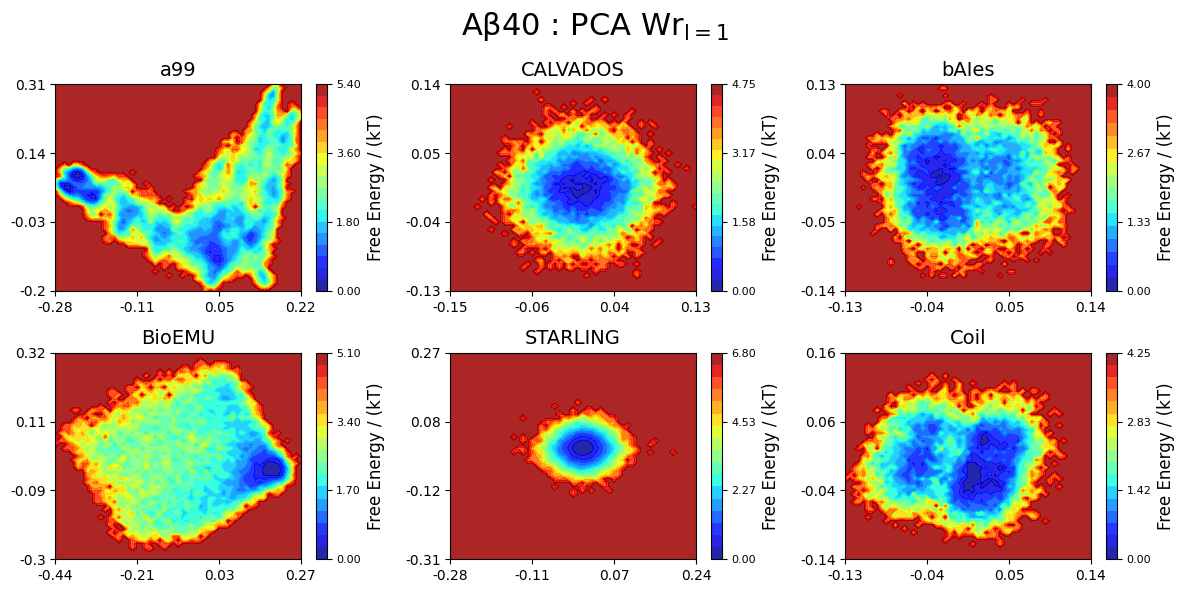

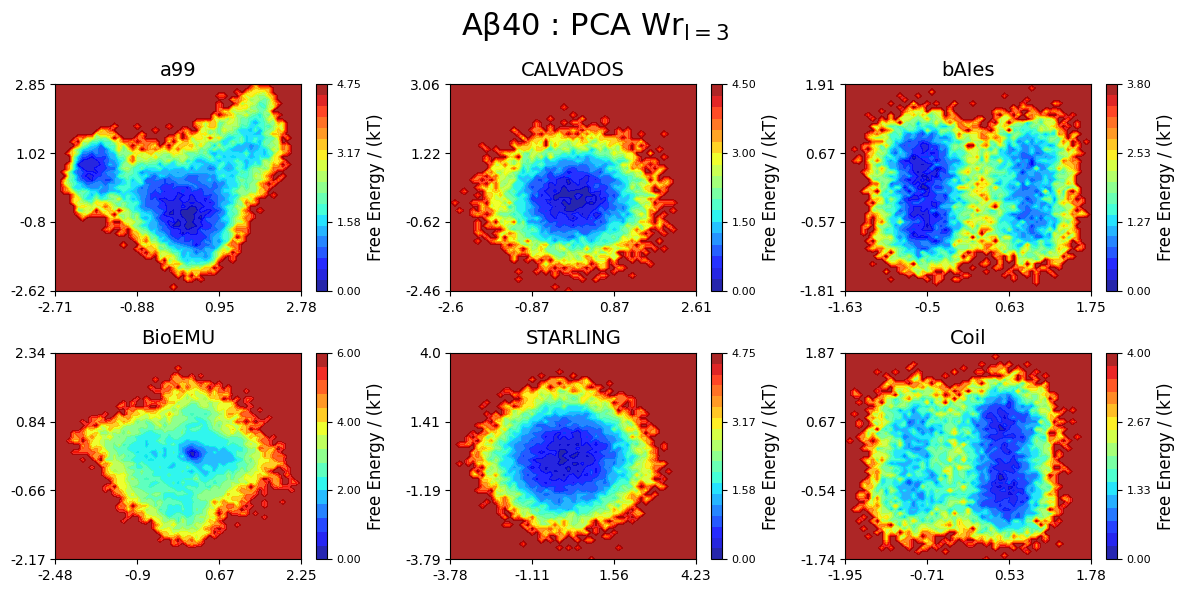

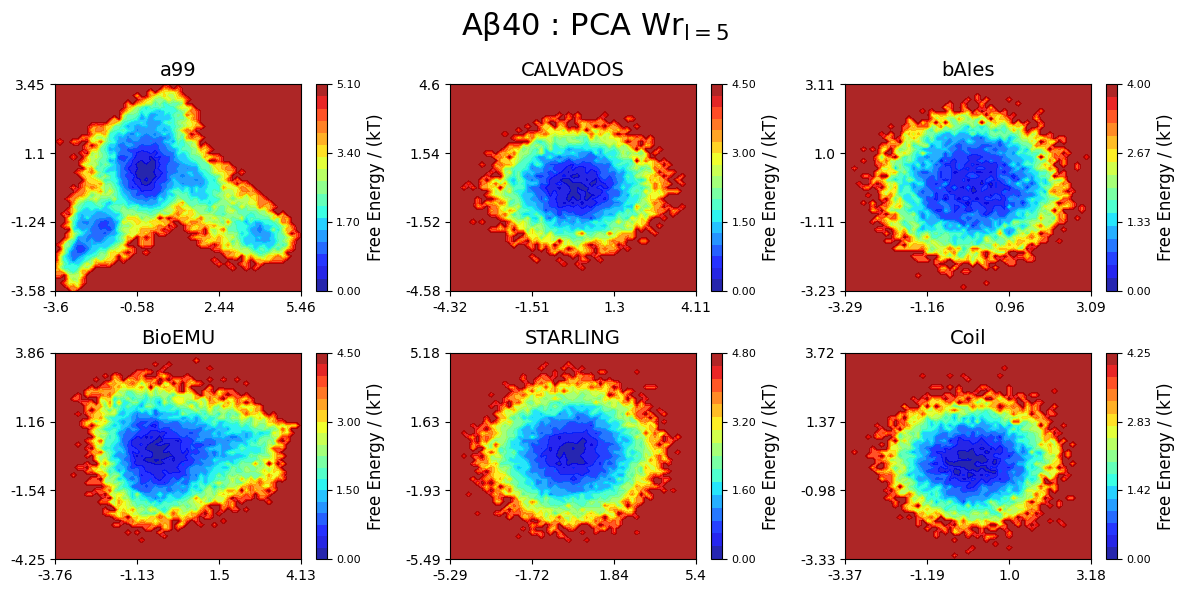

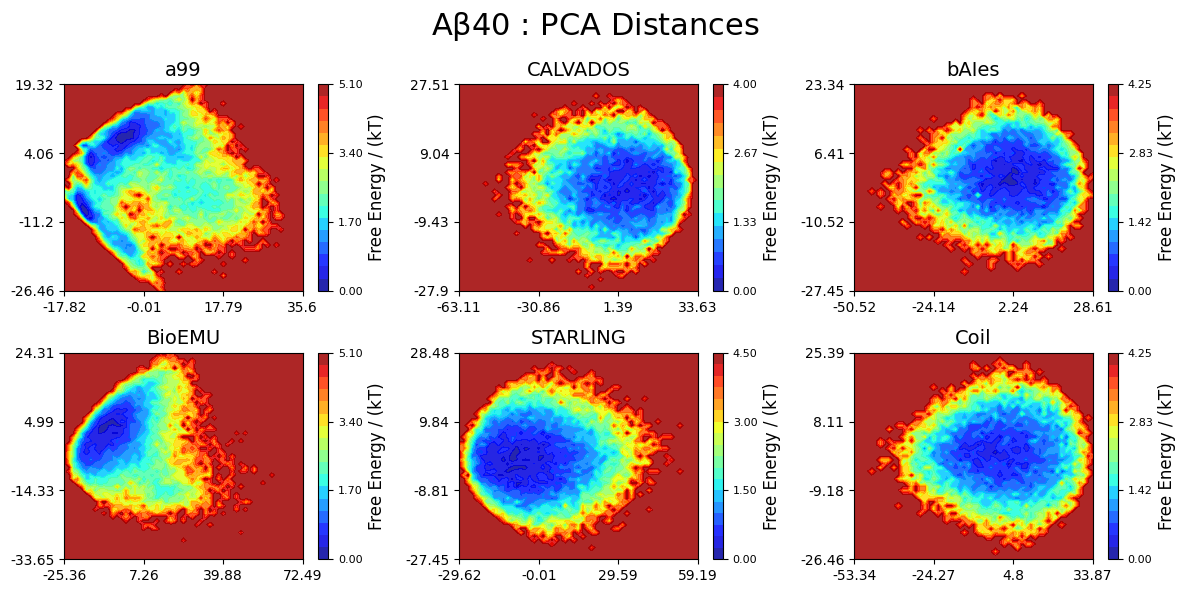

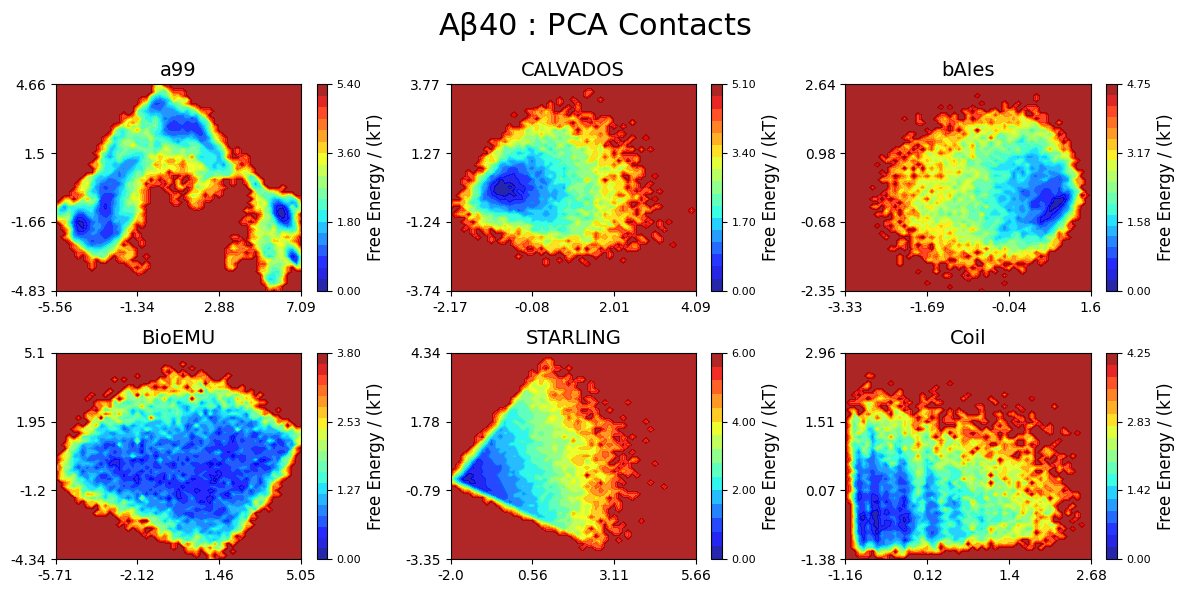

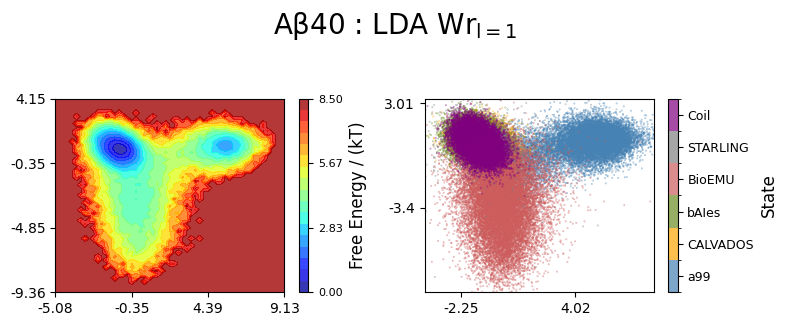

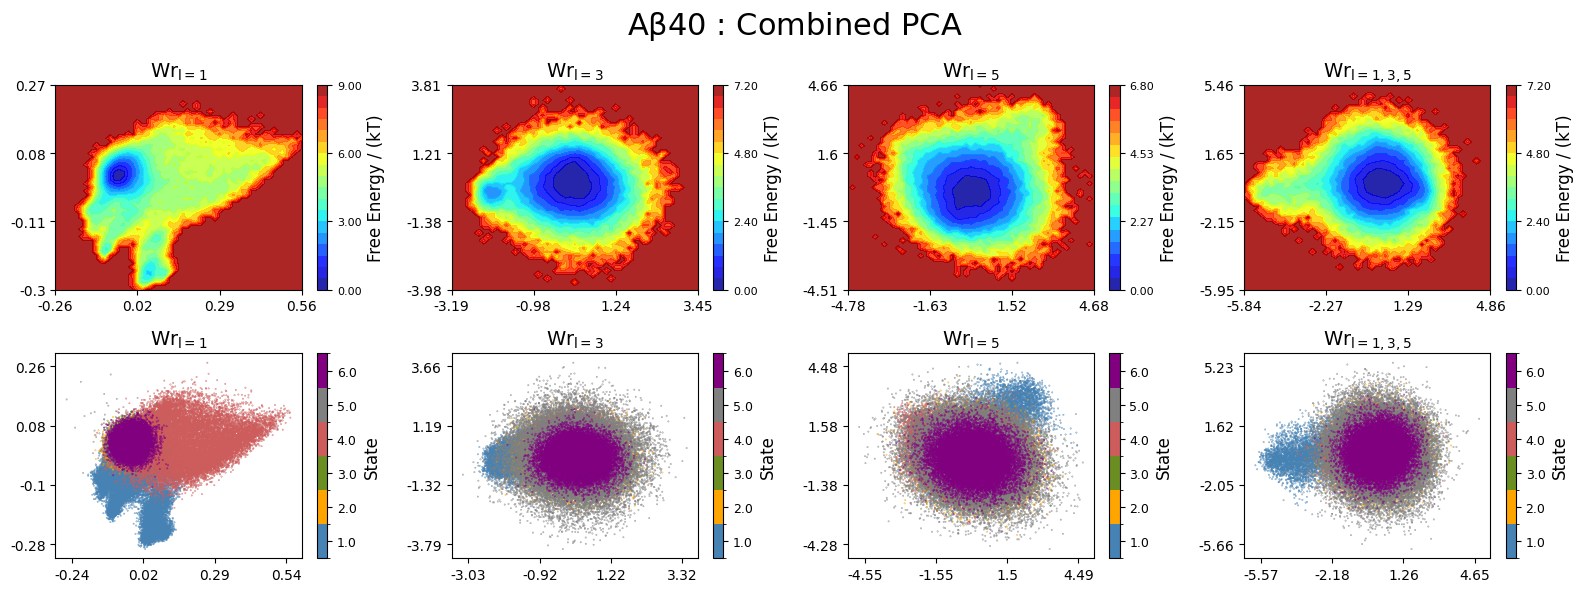

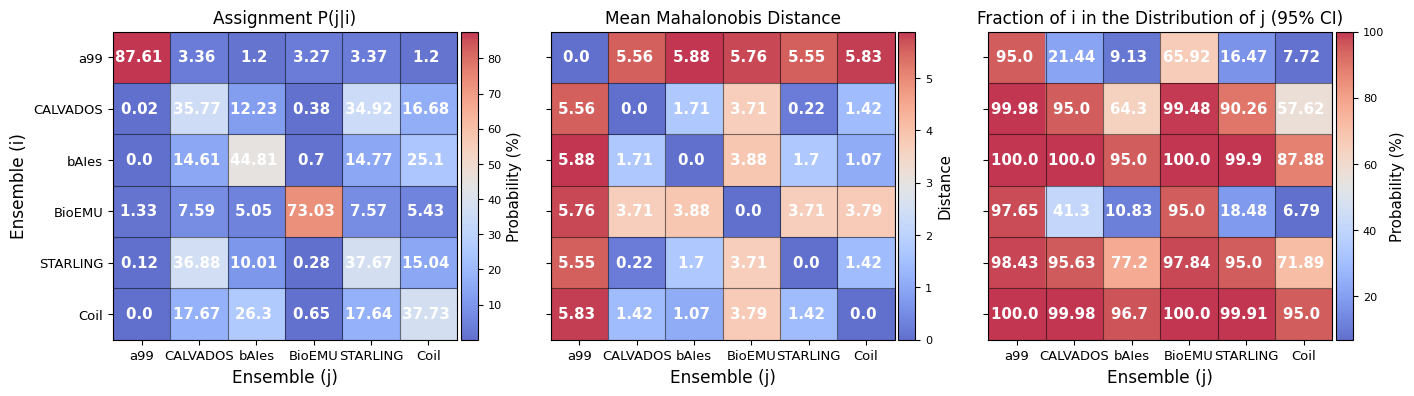

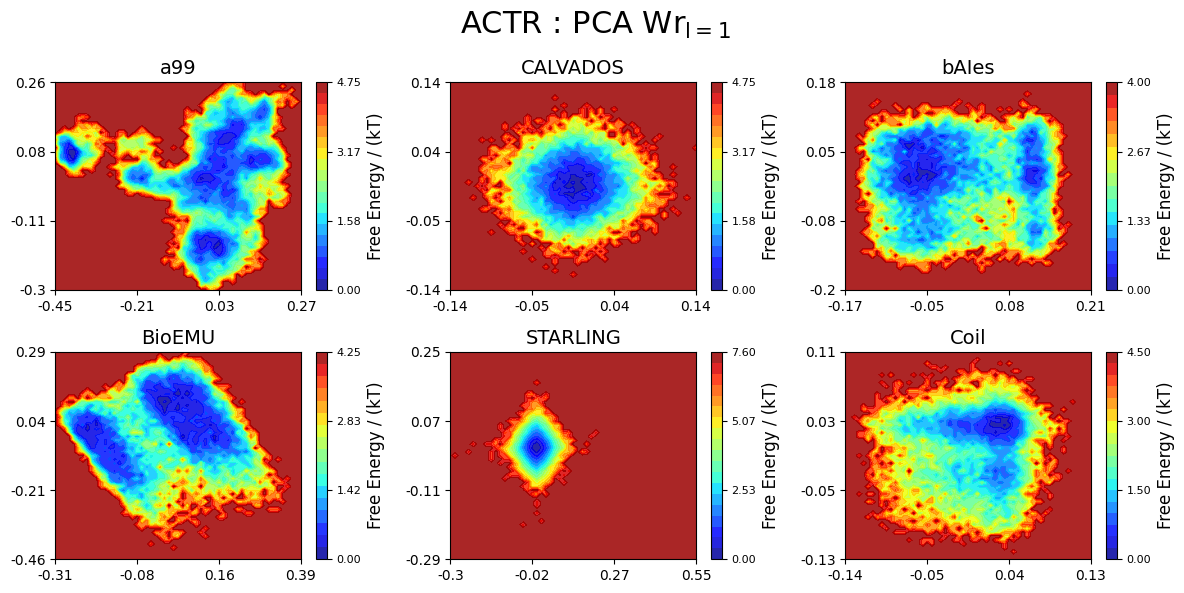

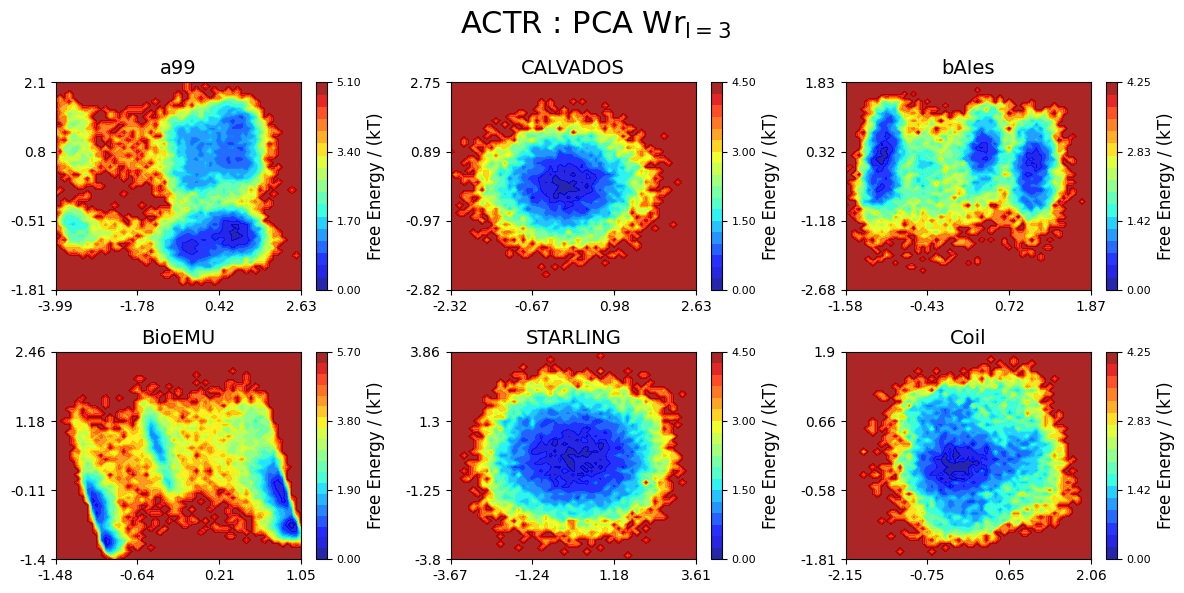

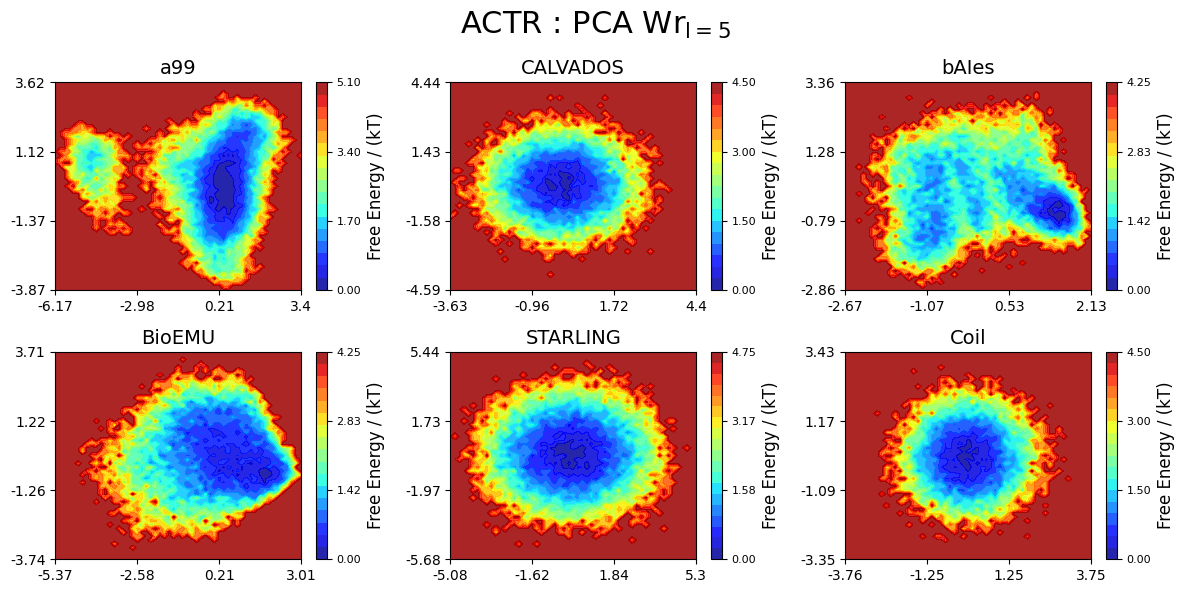

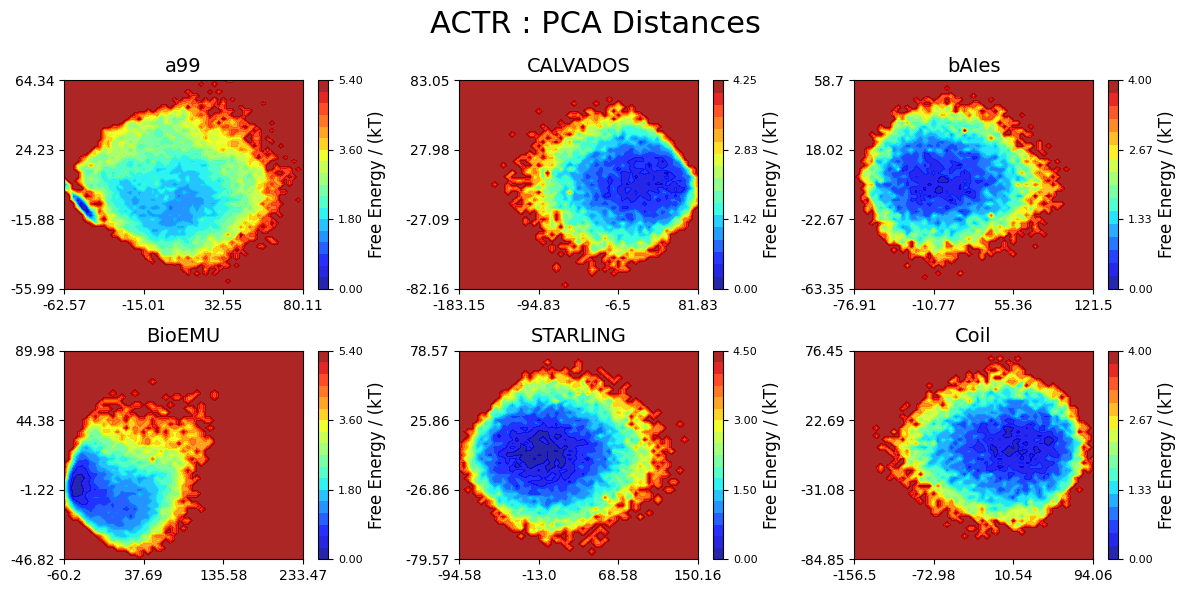

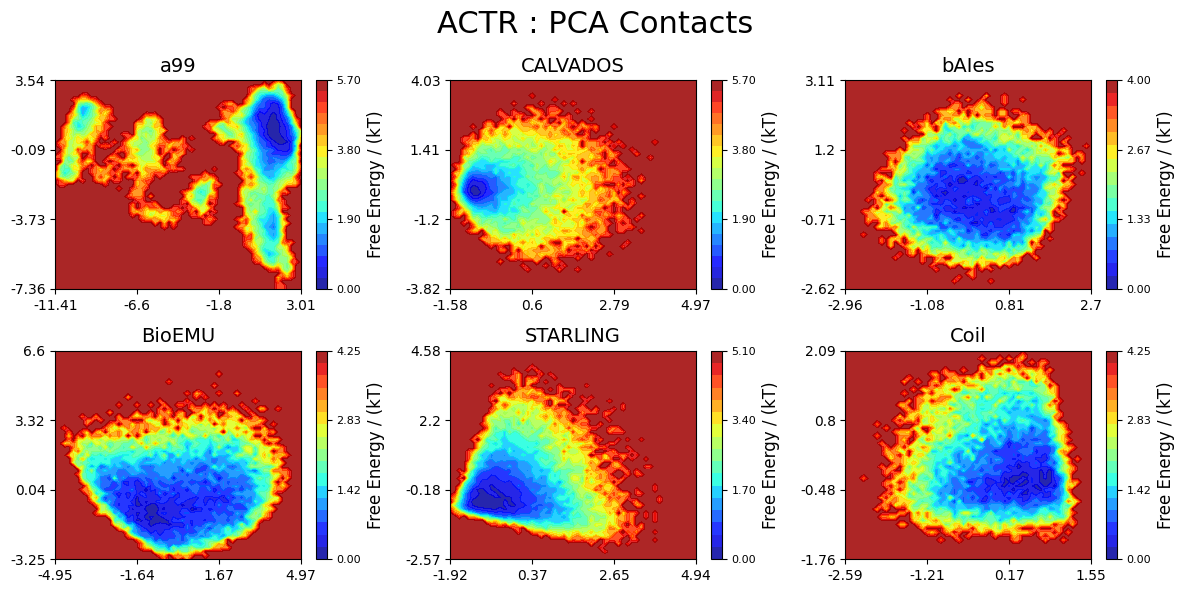

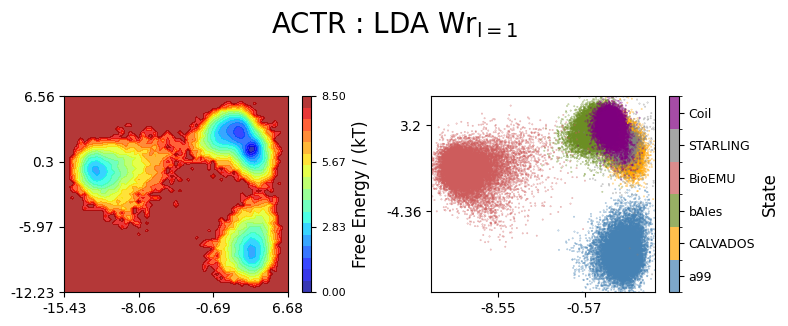

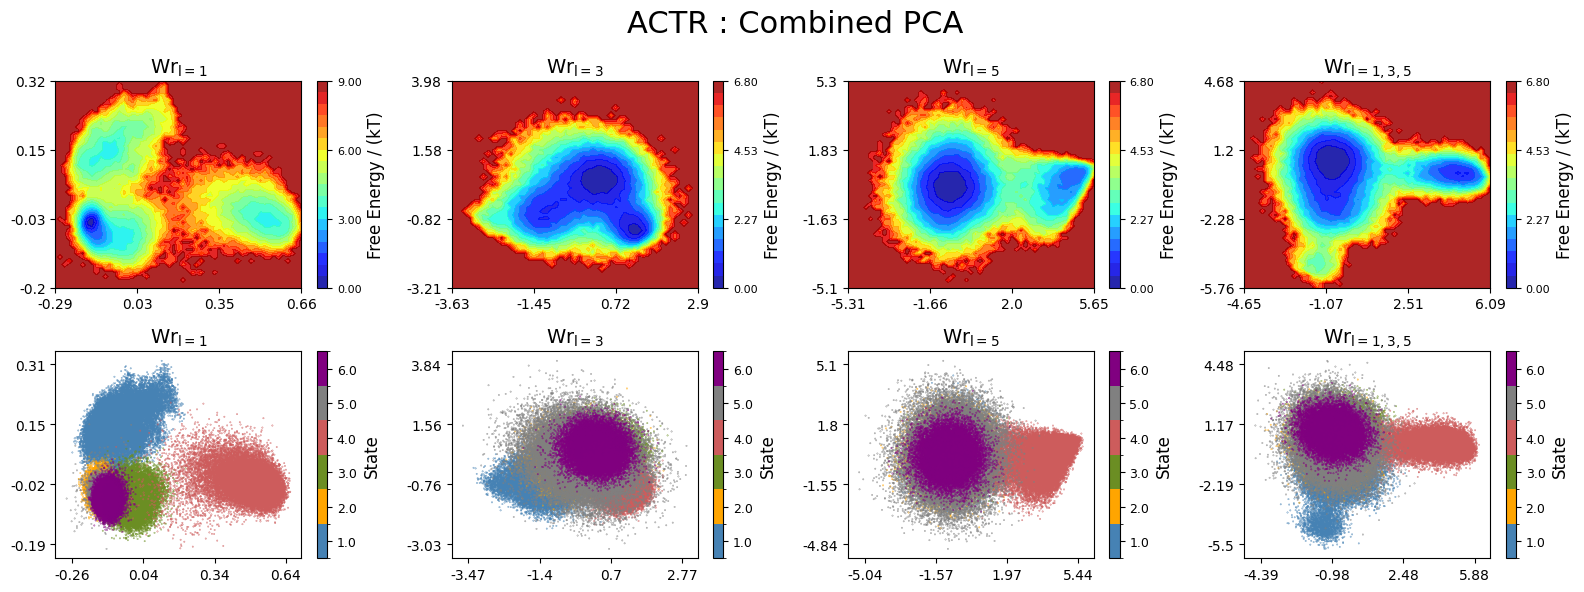

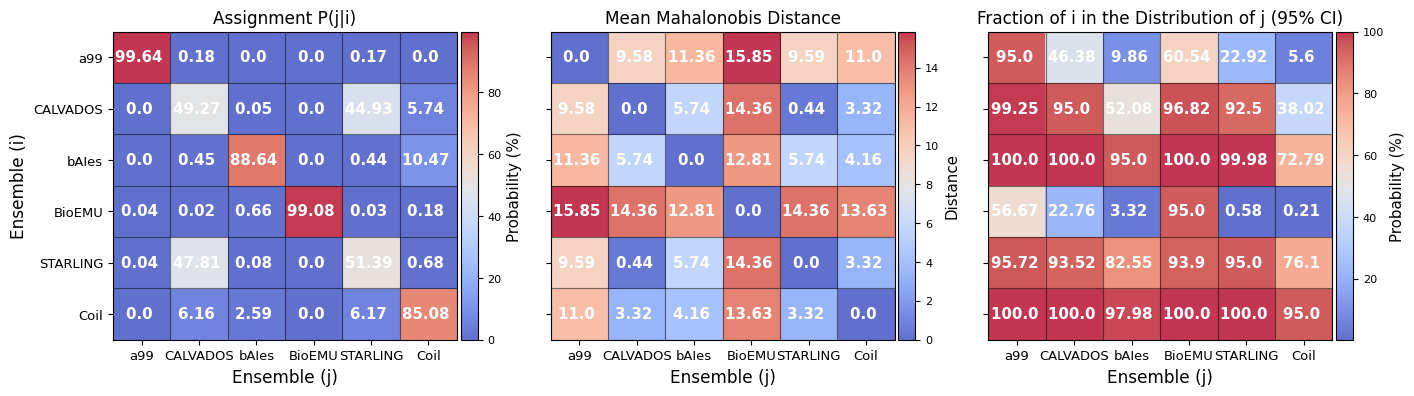

In [35]:
figsize = (12, 6)
title_size = 22
for index, ((key, value), protein) in enumerate(zip(files.items(), protein_names[:2])):
    all_writhes = []


    fig_wr1, axes_wr1 = plt.subplots(2, 3, figsize = figsize)
    fig_wr3, axes_wr3 = plt.subplots(2, 3, figsize = figsize)
    fig_wr5, axes_wr5 = plt.subplots(2, 3, figsize = figsize)
    fig_d, axes_d = plt.subplots(2, 3, figsize = figsize)
    fig_c, axes_c = plt.subplots(2, 3, figsize = figsize)
    fig_lda, axes_lda = plt.subplots(1, 2, figsize=(8, 3), )
    fig_wr_comb, axes_wr_comb = plt.subplots(2, 4, figsize=(16, 6))


    fig_wr1.suptitle(fr'{protein} : PCA $Wr_{{l=1}}$', size=title_size)
    fig_wr3.suptitle(fr'{protein} : PCA $Wr_{{l=3}}$', size=title_size)
    fig_wr5.suptitle(fr'{protein} : PCA $Wr_{{l=5}}$', size=title_size)
    fig_wr_comb.suptitle(fr'{protein} : Combined PCA', size=title_size)
    fig_d.suptitle(fr'{protein} : PCA Distances', size=title_size)
    fig_c.suptitle(fr'{protein} : PCA Contacts', size=title_size)
    fig_lda.suptitle(fr'{protein} : LDA $Wr_{{l=1}}$', y=1.07, size=20)

    lengths = []
    

    for pdb, dcd, axwr1, axwr3, axwr5, axd, axc, name in zip(*value.values(),
                                                        axes_wr1.flat,
                                                        axes_wr3.flat,
                                                        axes_wr5.flat,
                                                        axes_d.flat,
                                                        axes_c.flat,
                                                        names
                                                         ):
        
        atom_indices = md.load(pdb).top.select('name CA')
        traj = md.load(dcd, top=pdb, atom_indices=atom_indices).center_coordinates()
        writhe = Writhe(traj.xyz)
        features = [writhe.compute_writhe(l, cuda=True)['writhe_features'] for l in (1, 3, 5)]

        distances = ResidueDistances(index_0=np.arange(traj.n_residues), traj=traj)
        
        fes2d(pca(features[0], n_comp=2)[0], n_contours=18, alpha_contours=0.85, ax=axwr1, bins=55, title=name, mask=False)
        fes2d(pca(features[1], n_comp=2)[0], n_contours=18, alpha_contours=0.85, ax=axwr3, bins=55, title=name, mask=False)
        fes2d(pca(features[2], n_comp=2)[0], n_contours=18, alpha_contours=0.85, ax=axwr5, bins=55, title=name, mask=False)
        fes2d(pca(distances.distances, n_comp=2)[0], n_contours=18, alpha_contours=0.85, ax=axd, bins=55, title=name, mask=False)
        fes2d(pca(distances.contacts(1), n_comp=2)[0], n_contours=18, alpha_contours=0.85, ax=axc, bins=55, title=name, mask=False)
        all_writhes.append(features)
        lengths.append(traj.n_frames)



    c = np.concatenate([np.ones(i) * j for j, i in enumerate(lengths)])

    cax_fes, cax_scatter = axes_wr_comb.flat[:4], axes_wr_comb.flat[4:]

    for fax, sax, label, selection in zip(cax_fes, cax_scatter, (1, 3, 5, '1,3,5'), (0, 1, 2, [0, 1, 2])):

        wr = np.concatenate([wr[selection] if isinstance(selection, int)
              else np.concatenate(reindex_list(wr, selection), 1) for wr in all_writhes], 0)
        
        proj = pca(wr, dask = True if isinstance(selection, list) else False, n_comp = 2)[0]
        
        fes2d(proj[:, :2],
              n_contours=18,
              alpha_contours=0.85,
              ax=fax,
              bins=55,
              title = rf"$Wr_{{l={label}}}$",
              mask=False
             )
        
        proj2d(proj[:, :2],
               c = c,
               state_map=True,
               cmap=cmap,
               dot_size=0.08,
               ax=sax, 
               title = rf"$Wr_{{l={label}}}$"
              )
    del traj
    del writhe
    del distances
    lda = gaussian_comparison([wr[0] for wr in all_writhes])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    titles = ['Assignment P(j|i)', 'Mean Mahalonobis Distance', 'Fraction of i in the Distribution of j (95% CI)']
    cbar_labels = ['Probability (%)', 'Distance', 'Probability (%)']
    
    for i, (metric, ax, title, label) in enumerate(zip(lda[:-1], axes.flat, titles, cbar_labels)):
    
        annotated_matrix_plot(100 * metric if label != 'Distance' else metric,
                              title = title,
                              xlabel='Ensemble (j)',
                              ylabel="Ensemble (i)" if i == 0 else '',
                              cbar_label=label,
                              xticks=names,
                              yticks=names,
                              font_scale=.27,
                              xticks_top=False,
                              cmap='coolwarm',
                              hide_cbar_ticks=False,
                              grid=True,
                              decimals=2,
                              alpha=.8,
                              ax=ax
                         )
    lda[-1] = np.concatenate(lda[-1], 0)
    
    proj2d(lda[-1][:, :2], c = np.concatenate([i * np.ones(20000) for i in range(6)]),
    cmap=cmap, state_map=True, ax=axes_lda[1], cbar_labels=names, alpha=0.7, dot_size=.08)
    lda_ = ci_filter(lda[-1][:, :2], ci=.9995)
    axes_lda[1].set_xlim(lda_.T[0].min(), lda_.T[0].max())
    axes_lda[1].set_ylim(lda_.T[1].min(), lda_.T[1].max())
    
    fes2d(ci_filter(lda[-1][:, :2], ci=.9995), extend_border=.9, bins=55,
          n_contours=18, alpha_contours=.78, ax=axes_lda[0], mask=False)

    for fig in (fig_wr1, fig_wr3, fig_wr5, fig_d,fig_c, fig_wr_comb, fig_lda):
        fig.tight_layout()

    
        
    
    